# HiCL Hierarchical Gated Hippocampal MoE Word Span Demo

This notebook benchmarks the **HiCLSequenceModel** against the standard episodic recall tasks defined in the MemVal framework. We evaluate the model along two key dimensions:
1. **Sequence Length** (Working memory capacity mapping)
2. **Multiple Sequences** (Lifelong learning / Catastrophic forgetting test via DG-gated expert routing)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from memval.encoders import SymbolicEncoder, SymbolicDecoder
from memval.models.baselines import HiCLSequenceModel

def mean_recall_rate(recall_curve):
    return float(np.mean(recall_curve[1:]))

def memory_span(recall_curve, threshold=0.75):
    span = 0
    for r in recall_curve[1:]:
        if r >= threshold:
            span += 1
        else:
            break
    return span

def measure_recall_threshold(network, words, encoder, decoder, context_vec=None,
                              n_trials=10, noise_scale=0.05):
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            raw_pred = network.predict_next(noisy_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
    return success_counts / n_trials

def recall_fidelity(network, words, encoder, context_vec=None, n_trials=10, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    total_sim, count = 0.0, 0
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.reset_context()
        for i in range(len(words) - 1):
            network.current_t = i
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=context)
            sim = float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            total_sim += sim
            count += 1
    return total_sim / count

## 1. Sequence Length Benchmark

This benchmark tests working memory recall capacity by varying list length (5, 7, 10 words). A single-expert HiCL model is trained on each sequence, and serial position curves are plotted to evaluate pattern completion accuracy.

Evaluating HiCL sequence of length 5...
🧠 Hippocampal MoE: Feature dimension = 1600
Evaluating HiCL sequence of length 7...
🧠 Hippocampal MoE: Feature dimension = 1600
Evaluating HiCL sequence of length 10...
🧠 Hippocampal MoE: Feature dimension = 1600

--- Metric Summary Table: Sequence Length ---
---------------------------------------------------------------------------
Sequence Length           | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
5                         | 1.000      | 4               | 0.977          
7                         | 0.967      | 6               | 0.873          
10                        | 0.767      | 1               | 0.653          
---------------------------------------------------------------------------



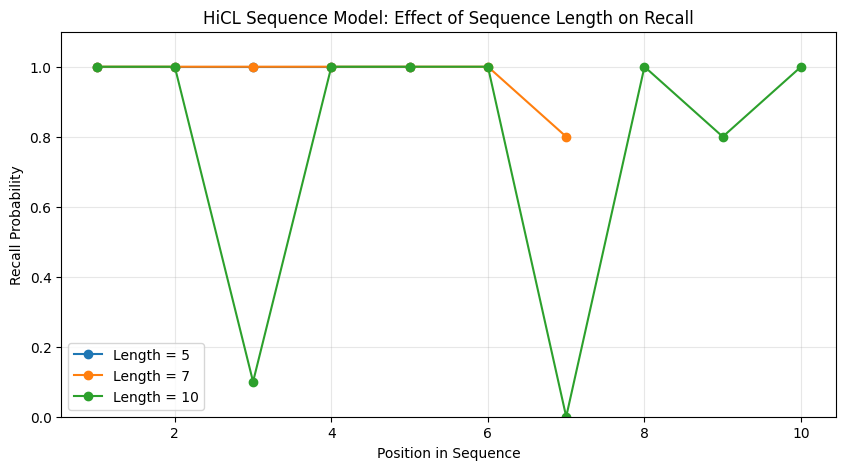

In [5]:
extended_vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit', 'apricot': 'fruit', 'fig': 'fruit', 'melon': 'fruit',
    'papaya': 'fruit', 'coconut': 'fruit'
}
ext_encoder = SymbolicEncoder(extended_vocab, embedding_dim=100, category_variance=0.2, seed=42)
ext_decoder = SymbolicDecoder(ext_encoder)
full_word_list = list(extended_vocab.keys())

seq_lengths = [5, 7, 10]
n_trials = 10
results_mrr_len = {}
results_span_len = {}
results_fidelity_len = {}
curves_len = {}

for length in seq_lengths:
    print(f"Evaluating HiCL sequence of length {length}...")
    current_words = full_word_list[:length]
    enc_words = ext_encoder.encode(current_words)
    context_seq = np.tile(np.array([1.0]), (len(current_words), 1))
    
    net = HiCLSequenceModel(
        encoder=ext_encoder,
        n_epochs_phase1=10,
        num_experts=2,
        device="cpu"
    )
    net.fit_sequence(enc_words, context_data=context_seq)
    
    probs_theta = measure_recall_threshold(net, current_words, ext_encoder, ext_decoder, n_trials=n_trials)
    curves_len[length] = probs_theta
    results_mrr_len[length] = mean_recall_rate(probs_theta)
    results_span_len[length] = memory_span(probs_theta)
    results_fidelity_len[length] = recall_fidelity(net, current_words, ext_encoder, n_trials=n_trials)

print("\n--- Metric Summary Table: Sequence Length ---")
print("-" * 75)
print(f"{'Sequence Length':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print("-" * 75)
for length in seq_lengths:
    print(f"{length:<25} | {results_mrr_len[length]:<10.3f} | {results_span_len[length]:<15} | {results_fidelity_len[length]:<15.3f}")
print("-" * 75 + "\n")

plt.figure(figsize=(10, 5))
for length in seq_lengths:
    plt.plot(range(1, length+1), curves_len[length], marker='o', label=f'Length = {length}')
plt.title("HiCL Sequence Model: Effect of Sequence Length on Recall")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. Multiple Sequences Benchmark (Lifelong Learning)

This benchmark tests sequence retention under sequential training of distinct categories (Fruits, Animals, Cars). A multi-expert HiCL model (`num_experts = 3`) is sequentially trained on the three sequences. The model uses online Dentate Gyrus (DG) prototype similarities to automatically route sequence elements during recall, preventing catastrophic forgetting.

In [3]:
vocab_multi = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'dog': 'animal', 'cat': 'animal', 'horse': 'animal', 'cow': 'animal', 'sheep': 'animal',
    'ford': 'car', 'chevy': 'car', 'dodge': 'car', 'toyota': 'car', 'honda': 'car'
}
encoder_multi = SymbolicEncoder(vocab_multi, embedding_dim=100, category_variance=0.2, seed=42)
decoder_multi = SymbolicDecoder(encoder_multi)

lists = {
    'fruits': ['apple', 'banana', 'orange', 'grape', 'pear'],
    'animals': ['dog', 'cat', 'horse', 'cow', 'sheep'],
    'cars': ['ford', 'chevy', 'dodge', 'toyota', 'honda']
}
context_map = {
    'fruits':  np.array([1.0]),
    'animals': np.array([2.0]),
    'cars':    np.array([3.0]),
}

net_multi = HiCLSequenceModel(
    encoder=encoder_multi,
    n_epochs_phase1=10,
    n_epochs_phase2=5,
    num_experts=3,
    device="cpu"
)
stages_data = []

for idx, (cat, words) in enumerate(lists.items()):
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    
    print(f"Stage {idx+1}: Training HiCL on {cat}...")
    net_multi.fit_sequence(enc_words, context_data=context_seq)
    
    stage_metrics = {}
    for c_cat in lists.keys():
        c_words = lists[c_cat]
        c_context = context_map[c_cat]
        
        probs_theta = measure_recall_threshold(net_multi, c_words, encoder_multi, decoder_multi, context_vec=c_context, n_trials=n_trials)
        mrr = mean_recall_rate(probs_theta)
        span = memory_span(probs_theta)
        fid = recall_fidelity(net_multi, c_words, encoder_multi, context_vec=c_context, n_trials=n_trials)
        stage_metrics[c_cat] = (mrr, span, fid)
        
    stages_data.append(stage_metrics)
    
    print("=" * 65)
    print(f"  Stage {idx+1} Primary Metrics (after training on: {cat})")
    print("-" * 65)
    print(f"  {'Category':<15} | {'MRR':<12} | {'Word Span':<12} | {'Recall Fidelity':<15}")
    print("-" * 65)
    for c_cat in lists.keys():
        mrr, span, fid = stage_metrics[c_cat]
        print(f"  {c_cat:<15} | {mrr:<12.3f} | {span:<12} | {fid:<15.3f}")
    print("=" * 65 + "\n")

Stage 1: Training HiCL on fruits...
🧠 Hippocampal MoE: Feature dimension = 1600
  Stage 1 Primary Metrics (after training on: fruits)
-----------------------------------------------------------------
  Category        | MRR          | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 1.000        | 4            | 0.910          
  animals         | 0.000        | 0            | -0.041         
  cars            | 0.000        | 0            | 0.012          

Stage 2: Training HiCL on animals...
  Stage 2 Primary Metrics (after training on: animals)
-----------------------------------------------------------------
  Category        | MRR          | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 1.000        | 4            | 0.813          
  animals         | 1.000        | 4            | 0.805          
  cars            | 0.000        | 0           

## 3. Expert Routing Dynamics

Here we inspect the cosine similarities between the model's Dentate Gyrus (DG) output for each list and the stored expert prototypes. This allows us to verify that the gating network properly routes the input sequences to distinct hippocampal experts based on semantic overlap.

In [4]:
print("--- Expert Routing Matrix ---")
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    x = net_multi._to_torch(enc_words)
    net_multi.model.eval()
    with torch.no_grad():
        features = net_multi.model.feature_extractor(x).view(x.size(0), -1)
        similarities = []
        for i in range(3):
            dg_output, _ = net_multi.model.hippocampal_experts[i](features)
            dg_norm = torch.nn.functional.normalize(dg_output, p=2, dim=1)
            proto_norm = torch.nn.functional.normalize(net_multi.model.dg_prototypes[i].unsqueeze(0), p=2, dim=1)
            sim = (dg_norm @ proto_norm.T).mean().item()
            similarities.append(sim)
        
    print(f"Sequence: {cat:<8} -> Expert similarities: " + " | ".join([f"Exp {i}: {s:.3f}" for i, s in enumerate(similarities)]))

--- Expert Routing Matrix ---
Sequence: fruits   -> Expert similarities: Exp 0: 0.768 | Exp 1: -0.502 | Exp 2: -0.486
Sequence: animals  -> Expert similarities: Exp 0: -0.291 | Exp 1: 0.604 | Exp 2: -0.475
Sequence: cars     -> Expert similarities: Exp 0: -0.105 | Exp 1: -0.266 | Exp 2: 0.374
